In [2]:
import sys
sys.path.insert(0, '../..')

import os
import json
import ast
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from pathlib import Path

# plot style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

# output folder for plots
Path('../../data/processed/plots').mkdir(parents=True, exist_ok=True)
Path('../../data/processed').mkdir(parents=True, exist_ok=True)

print("✅ Imports done")

✅ Imports done


In [3]:
# We load everything here once
# ratings_small for dev speed — full ratings.csv needs PySpark

DATA = '../../data/raw/'

metadata      = pd.read_csv(DATA + 'movies_metadata.csv', low_memory=False)
credits       = pd.read_csv(DATA + 'credits.csv')
keywords      = pd.read_csv(DATA + 'keywords.csv')
links         = pd.read_csv(DATA + 'links.csv')
links_small   = pd.read_csv(DATA + 'links_small.csv')
ratings       = pd.read_csv(DATA + 'ratings_small.csv')
# ratings_full loaded with PySpark in Week 3 — not here

print("All 7 files loaded ✅\n")
print(f"{'FILE':<25} {'ROWS':>10}  {'COLS':>5}  COLUMNS")
print("─" * 80)
for name, df in [
    ('movies_metadata', metadata),
    ('credits',         credits),
    ('keywords',        keywords),
    ('links',           links),
    ('links_small',     links_small),
    ('ratings_small',   ratings),
]:
    print(f"{name:<25} {df.shape[0]:>10,}  {df.shape[1]:>5}  "
          f"{list(df.columns)}")

All 7 files loaded ✅

FILE                            ROWS   COLS  COLUMNS
────────────────────────────────────────────────────────────────────────────────
movies_metadata               45,466     24  ['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id', 'imdb_id', 'original_language', 'original_title', 'overview', 'popularity', 'poster_path', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title', 'video', 'vote_average', 'vote_count']
credits                       45,476      3  ['cast', 'crew', 'id']
keywords                      46,419      2  ['id', 'keywords']
links                         45,843      3  ['movieId', 'imdbId', 'tmdbId']
links_small                    9,125      3  ['movieId', 'imdbId', 'tmdbId']
ratings_small                100,004      4  ['userId', 'movieId', 'rating', 'timestamp']


In [4]:
print("MISSING VALUES ANALYSIS")
print("=" * 60)

for name, df in [
    ('movies_metadata', metadata),
    ('credits',         credits),
    ('keywords',        keywords),
    ('links',           links),
    ('ratings_small',   ratings),
]:
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    pct   = (nulls / len(df) * 100).round(2)
    print(f"\n📄 {name}")
    if len(nulls) == 0:
        print("   No missing values ✅")
    else:
        for col in nulls.index:
            print(f"   {col:<30} {nulls[col]:>7,} missing  ({pct[col]}%)")

MISSING VALUES ANALYSIS

📄 movies_metadata
   belongs_to_collection           40,972 missing  (90.12%)
   homepage                        37,684 missing  (82.88%)
   imdb_id                             17 missing  (0.04%)
   original_language                   11 missing  (0.02%)
   overview                           954 missing  (2.1%)
   popularity                           5 missing  (0.01%)
   poster_path                        386 missing  (0.85%)
   production_companies                 3 missing  (0.01%)
   production_countries                 3 missing  (0.01%)
   release_date                        87 missing  (0.19%)
   revenue                              6 missing  (0.01%)
   runtime                            263 missing  (0.58%)
   spoken_languages                     6 missing  (0.01%)
   status                              87 missing  (0.19%)
   tagline                         25,054 missing  (55.1%)
   title                                6 missing  (0.01%)
   video    

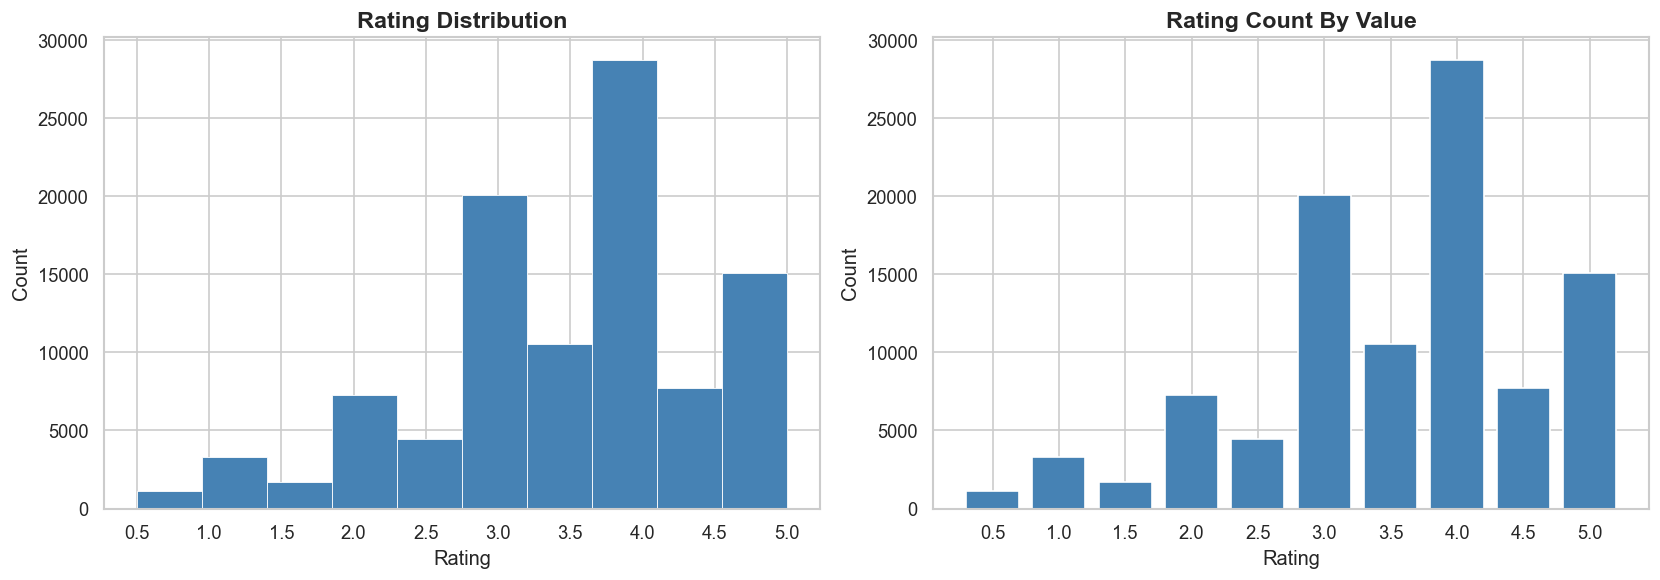


Rating stats:
count    100004.000
mean          3.544
std           1.058
min           0.500
25%           3.000
50%           4.000
75%           4.000
max           5.000
Name: rating, dtype: float64

Most common rating : 4.0
% ratings >= 3.0   : 82.2%


In [5]:
# Rating Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(ratings['rating'], bins=10,
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Rating Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_xticks([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

# Countplot
rating_counts = ratings['rating'].value_counts().sort_index()
axes[1].bar(rating_counts.index.astype(str),
            rating_counts.values, color='steelblue')
axes[1].set_title('Rating Count By Value', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../../data/processed/plots/01_rating_distribution.png',
            bbox_inches='tight')
plt.show()

print(f"\nRating stats:")
print(ratings['rating'].describe().round(3))
print(f"\nMost common rating : {ratings['rating'].mode()[0]}")
print(f"% ratings >= 3.0   : {(ratings['rating'] >= 3.0).mean()*100:.1f}%")

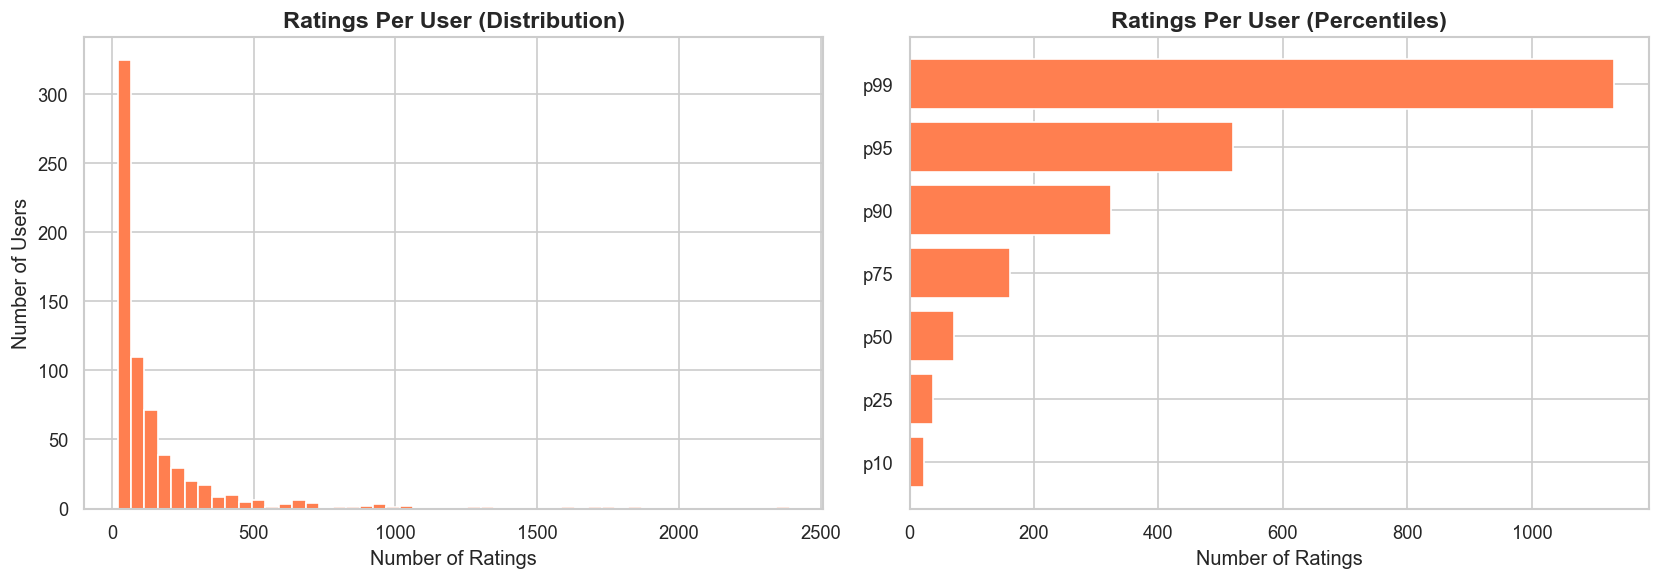

Total users         : 671
Avg ratings/user    : 149.0
Median ratings/user : 71
Users with < 5      : 0  (0.0%)
Users with > 100    : 258  (38.5%)


In [7]:
# User Activity Analysis

ratings_per_user = ratings.groupby('userId')['rating'].count().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(ratings_per_user, bins=50,
             color='coral', edgecolor='white')
axes[0].set_title('Ratings Per User (Distribution)',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Number of Users')

# Percentiles
pcts = [10, 25, 50, 75, 90, 95, 99]
vals = [ratings_per_user.quantile(p/100) for p in pcts]
axes[1].barh([f"p{p}" for p in pcts], vals, color='coral')
axes[1].set_title('Ratings Per User (Percentiles)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.savefig('../../data/processed/plots/02_user_activity.png',
            bbox_inches='tight')
plt.show()

print(f"Total users         : {ratings['userId'].nunique():,}")
print(f"Avg ratings/user    : {ratings_per_user.mean():.1f}")
print(f"Median ratings/user : {ratings_per_user.median():.0f}")
print(f"Users with < 5      : {(ratings_per_user < 5).sum():,}  "
      f"({(ratings_per_user < 5).mean()*100:.1f}%)")
print(f"Users with > 100    : {(ratings_per_user > 100).sum():,}  "
      f"({(ratings_per_user > 100).mean()*100:.1f}%)")

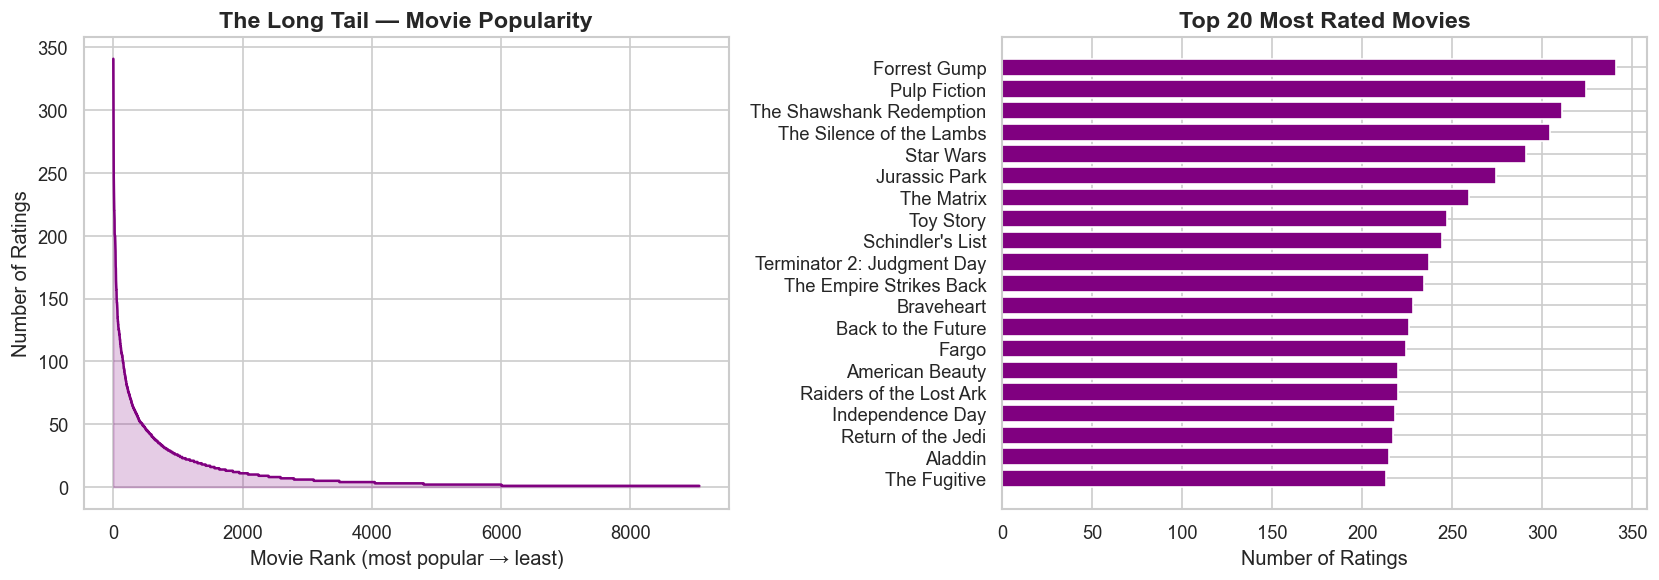

Total unique movies      : 9,066
Top 1% movies get        : 15.9% of ratings
Top 10% movies get       : 59.9% of ratings
Movies with only 1 rating: 3,063


In [9]:
# Movie Popularity(The Long Tail)
ratings_per_movie = ratings.groupby('movieId')['rating'].count().sort_values(
    ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Long tail curve
axes[0].plot(range(len(ratings_per_movie)),
             ratings_per_movie.values,
             color='purple', linewidth=1.5)
axes[0].fill_between(range(len(ratings_per_movie)),
                     ratings_per_movie.values,
                     alpha=0.2, color='purple')
axes[0].set_title('The Long Tail — Movie Popularity',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Movie Rank (most popular → least)')
axes[0].set_ylabel('Number of Ratings')

# Top 20 most rated movies
top20 = ratings_per_movie.head(20)
movie_titles = metadata[['id', 'title']].copy()
movie_titles['id'] = pd.to_numeric(movie_titles['id'], errors='coerce')
links_map = links[['movieId', 'tmdbId']].dropna()
links_map['tmdbId'] = pd.to_numeric(links_map['tmdbId'], errors='coerce')
merged = top20.reset_index().merge(
    links_map, on='movieId', how='left'
).merge(
    movie_titles, left_on='tmdbId', right_on='id', how='left'
)
merged['label'] = merged['title'].fillna(merged['movieId'].astype(str))
axes[1].barh(merged['label'].head(20)[::-1],
             merged['rating'].head(20)[::-1],
             color='purple')
axes[1].set_title('Top 20 Most Rated Movies',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Ratings')

plt.tight_layout()
plt.savefig('../../data/processed/plots/03_movie_popularity.png',
            bbox_inches='tight')
plt.show()

top1pct  = int(len(ratings_per_movie) * 0.01)
top10pct = int(len(ratings_per_movie) * 0.10)
total    = ratings_per_movie.sum()

print(f"Total unique movies      : {len(ratings_per_movie):,}")
print(f"Top 1% movies get        : "
      f"{ratings_per_movie.head(top1pct).sum()/total*100:.1f}% of ratings")
print(f"Top 10% movies get       : "
      f"{ratings_per_movie.head(top10pct).sum()/total*100:.1f}% of ratings")
print(f"Movies with only 1 rating: "
      f"{(ratings_per_movie == 1).sum():,}")

  SPARSITY ANALYSIS
  Users              :        671
  Movies             :      9,066
  Ratings observed   :    100,004
  Possible ratings   :  6,083,286
  Sparsity           :    98.3561%

  Interpretation:
  Only 1.6439% of the user-movie matrix is filled.
  This extreme sparsity is WHY traditional CF struggles
  and WHY generative retrieval models (GRank, HSTU) are needed.


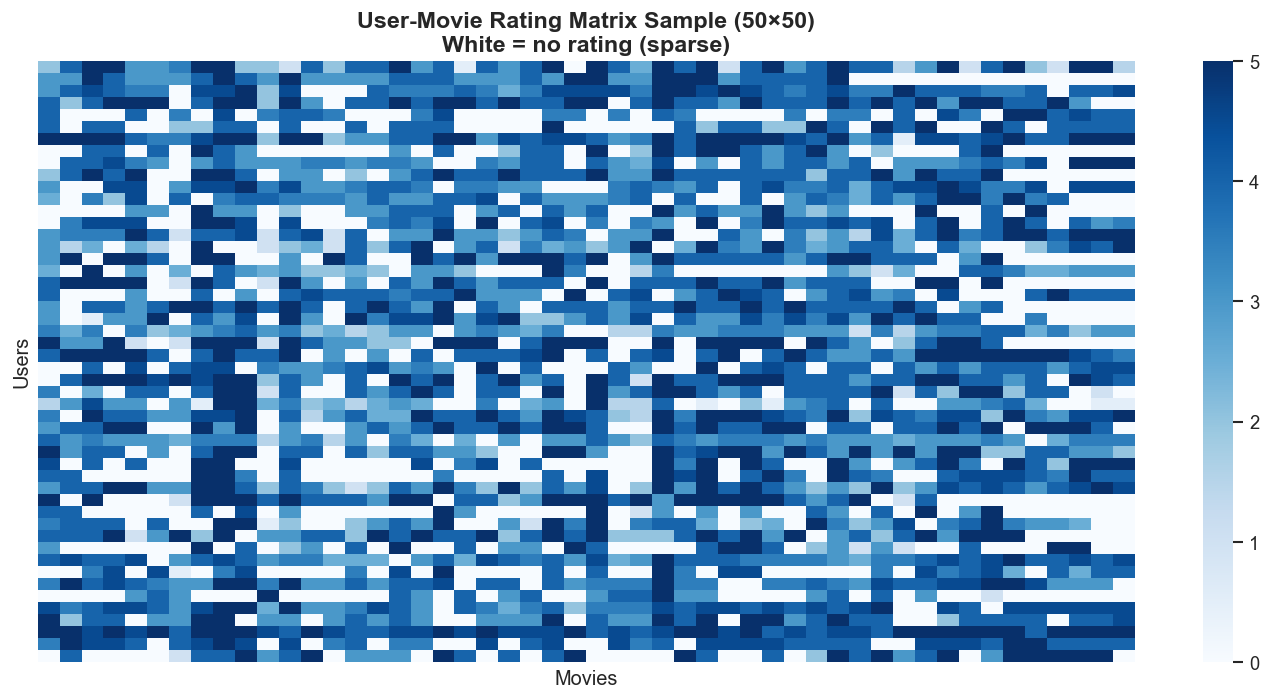

In [10]:
# Sparsity Analysis
n_users  = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

possible  = n_users * n_movies
sparsity  = 1 - (n_ratings / possible)

print("=" * 50)
print("  SPARSITY ANALYSIS")
print("=" * 50)
print(f"  Users              : {n_users:>10,}")
print(f"  Movies             : {n_movies:>10,}")
print(f"  Ratings observed   : {n_ratings:>10,}")
print(f"  Possible ratings   : {possible:>10,}")
print(f"  Sparsity           : {sparsity*100:>10.4f}%")
print("=" * 50)
print(f"\n  Interpretation:")
print(f"  Only {(1-sparsity)*100:.4f}% of the user-movie matrix is filled.")
print(f"  This extreme sparsity is WHY traditional CF struggles")
print(f"  and WHY generative retrieval models (GRank, HSTU) are needed.")

# Visualise as a small sample heatmap
sample_users  = ratings['userId'].value_counts().head(50).index
sample_movies = ratings['movieId'].value_counts().head(50).index
matrix_sample = ratings[
    ratings['userId'].isin(sample_users) &
    ratings['movieId'].isin(sample_movies)
].pivot_table(index='userId', columns='movieId',
              values='rating', fill_value=0)

plt.figure(figsize=(12, 6))
sns.heatmap(matrix_sample,
            cmap='Blues', cbar=True,
            xticklabels=False, yticklabels=False)
plt.title('User-Movie Rating Matrix Sample (50×50)\n'
          'White = no rating (sparse)', fontsize=14, fontweight='bold')
plt.xlabel('Movies')
plt.ylabel('Users')
plt.tight_layout()
plt.savefig('../../data/processed/plots/04_sparsity_heatmap.png',
            bbox_inches='tight')
plt.show()

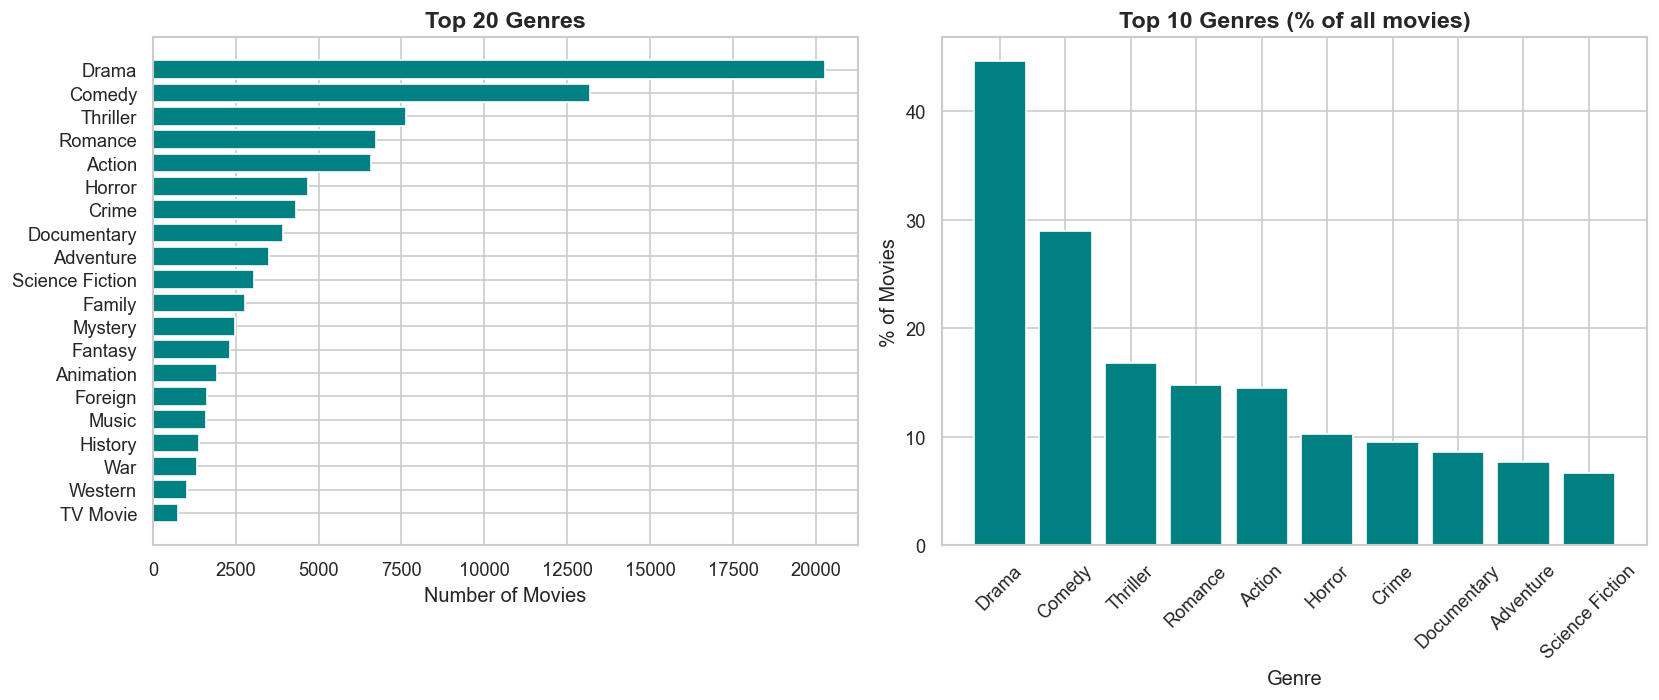

Movies with no genre: 2,442 (5.4%)

Top 5 genres: ['Drama', 'Comedy', 'Thriller', 'Romance', 'Action']


In [11]:
# Genre Analysis
def parse_genres(genre_str):
    try:
        return [g['name'] for g in ast.literal_eval(genre_str)]
    except:
        return []

metadata['genres_list'] = metadata['genres'].apply(parse_genres)

all_genres   = [g for gl in metadata['genres_list'] for g in gl]
genre_counts = Counter(all_genres).most_common(20)
genres_df    = pd.DataFrame(genre_counts, columns=['genre', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar chart
axes[0].barh(genres_df['genre'][::-1],
             genres_df['count'][::-1],
             color='teal')
axes[0].set_title('Top 20 Genres', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Movies')

# Movies per genre as % of total
genres_df['pct'] = (genres_df['count'] / len(metadata) * 100).round(1)
axes[1].bar(genres_df['genre'][:10],
            genres_df['pct'][:10],
            color='teal')
axes[1].set_title('Top 10 Genres (% of all movies)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Genre')
axes[1].set_ylabel('% of Movies')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../../data/processed/plots/05_genre_distribution.png',
            bbox_inches='tight')
plt.show()

# Movies with NO genre
no_genre = metadata['genres_list'].apply(len) == 0
print(f"Movies with no genre: {no_genre.sum():,} "
      f"({no_genre.mean()*100:.1f}%)")
print(f"\nTop 5 genres: "
      f"{[g[0] for g in genre_counts[:5]]}")

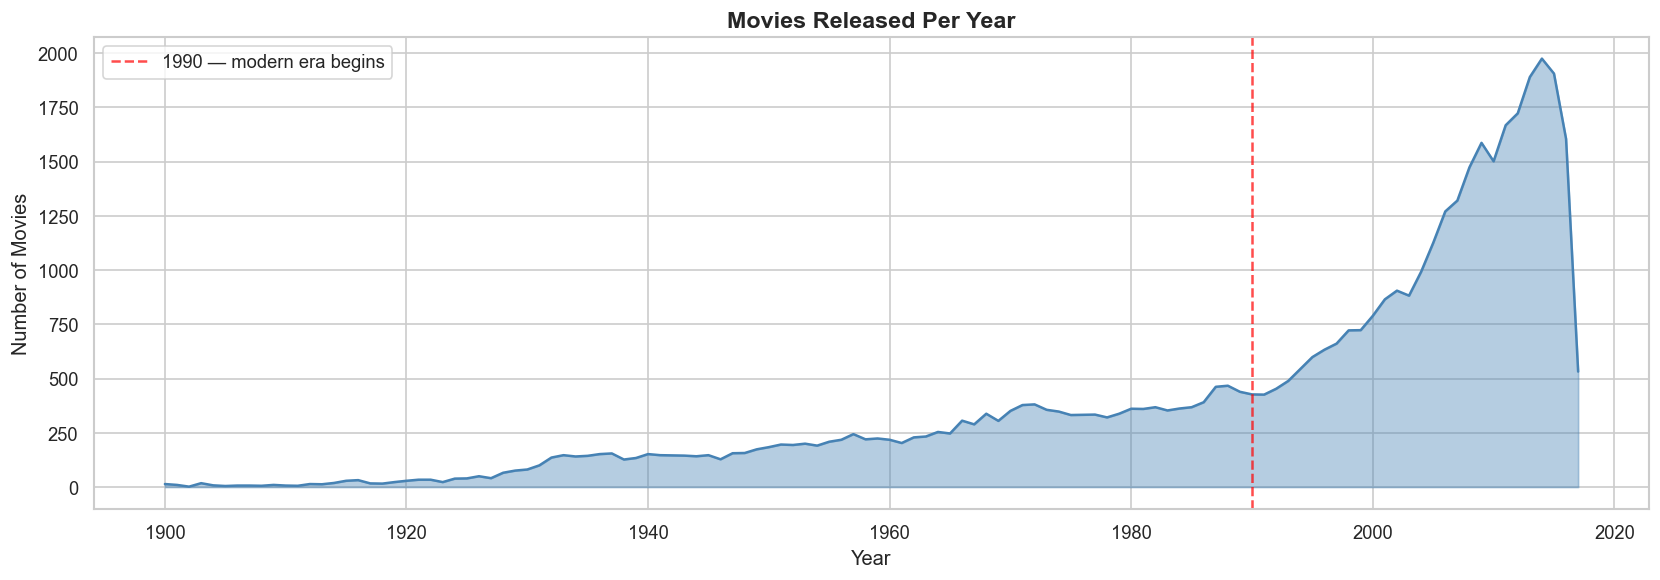

Earliest movie: 1874
Latest movie  : 2020
Missing dates : 90
Post-1990     : 29,684 movies (65.3%)


In [12]:
# Movie Released Per year
metadata['release_date'] = pd.to_datetime(
    metadata['release_date'], errors='coerce')
metadata['year'] = metadata['release_date'].dt.year

yearly = metadata['year'].value_counts().sort_index()
yearly = yearly[(yearly.index >= 1900) & (yearly.index <= 2017)]

plt.figure(figsize=(14, 5))
plt.fill_between(yearly.index, yearly.values,
                 alpha=0.4, color='steelblue')
plt.plot(yearly.index, yearly.values,
         color='steelblue', linewidth=1.5)
plt.title('Movies Released Per Year',
          fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.axvline(x=1990, color='red', linestyle='--',
            alpha=0.7, label='1990 — modern era begins')
plt.legend()
plt.tight_layout()
plt.savefig('../../data/processed/plots/06_movies_per_year.png',
            bbox_inches='tight')
plt.show()

print(f"Earliest movie: {metadata['year'].min():.0f}")
print(f"Latest movie  : {metadata['year'].max():.0f}")
print(f"Missing dates : {metadata['year'].isnull().sum():,}")
print(f"Post-1990     : {(metadata['year'] >= 1990).sum():,} movies "
      f"({(metadata['year'] >= 1990).mean()*100:.1f}%)")

In [14]:
# Dataset Relationship Check
# Convert all IDs to numeric safely
metadata['id'] = pd.to_numeric(metadata['id'], errors='coerce')
credits['id']  = pd.to_numeric(credits['id'],  errors='coerce')
keywords['id'] = pd.to_numeric(keywords['id'], errors='coerce')
links['tmdbId']= pd.to_numeric(links['tmdbId'],errors='coerce')

meta_ids    = set(metadata['id'].dropna().astype(int))
credit_ids  = set(credits['id'].dropna().astype(int))
keyword_ids = set(keywords['id'].dropna().astype(int))
link_tmdb   = set(links['tmdbId'].dropna().astype(int))
rated_ids   = set(ratings['movieId'].unique())
link_movie  = set(links['movieId'].unique())

# Map rated movieIds to tmdbIds
rated_tmdb = set(
    links[links['movieId'].isin(rated_ids)]['tmdbId']
    .dropna().astype(int)
)

print("ID ALIGNMENT ACROSS ALL 7 FILES")
print("=" * 55)
print(f"movies_metadata IDs      : {len(meta_ids):>8,}")
print(f"credits IDs              : {len(credit_ids):>8,}")
print(f"keywords IDs             : {len(keyword_ids):>8,}")
print(f"links tmdbIds            : {len(link_tmdb):>8,}")
print(f"ratings movieIds         : {len(rated_ids):>8,}")
print("─" * 55)
print(f"metadata ∩ credits       : {len(meta_ids & credit_ids):>8,}")
print(f"metadata ∩ keywords      : {len(meta_ids & keyword_ids):>8,}")
print(f"metadata ∩ links         : {len(meta_ids & link_tmdb):>8,}")
print(f"rated movies in metadata : {len(rated_tmdb & meta_ids):>8,}")
print("=" * 55)
print(f"\n⚠️  Movies rated but NOT in metadata: "
      f"{len(rated_tmdb - meta_ids):,}")
print(f"⚠️  Movies in metadata NOT rated: "
      f"{len(meta_ids - rated_tmdb):,}")
print(f"\nThese gaps will be handled in Day 3 cleaning.")


ID ALIGNMENT ACROSS ALL 7 FILES
movies_metadata IDs      :   45,433
credits IDs              :   45,432
keywords IDs             :   45,432
links tmdbIds            :   45,594
ratings movieIds         :    9,066
───────────────────────────────────────────────────────
metadata ∩ credits       :   45,432
metadata ∩ keywords      :   45,432
metadata ∩ links         :   45,433
rated movies in metadata :    9,025

⚠️  Movies rated but NOT in metadata: 23
⚠️  Movies in metadata NOT rated: 36,408

These gaps will be handled in Day 3 cleaning.


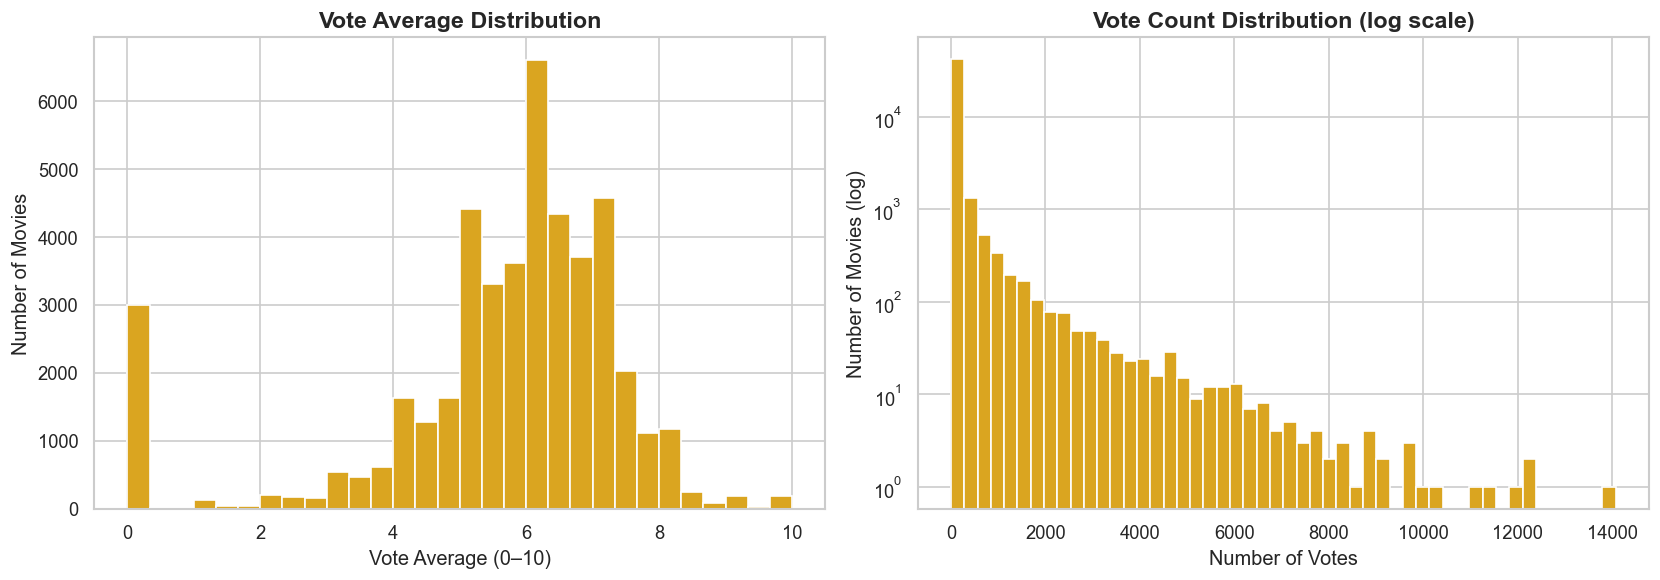

Vote average — mean  : 5.62
Vote average — median: 6.00
Movies with 0 votes  : 2,899


In [15]:
# Vote Average Distribution
metadata['vote_average'] = pd.to_numeric(
    metadata['vote_average'], errors='coerce')
metadata['vote_count']   = pd.to_numeric(
    metadata['vote_count'], errors='coerce')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Vote average distribution
axes[0].hist(
    metadata['vote_average'].dropna(),
    bins=30, color='goldenrod', edgecolor='white')
axes[0].set_title('Vote Average Distribution',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Vote Average (0–10)')
axes[0].set_ylabel('Number of Movies')

# Vote count distribution (log scale)
axes[1].hist(
    metadata['vote_count'].dropna(),
    bins=50, color='goldenrod', edgecolor='white',
    log=True)
axes[1].set_title('Vote Count Distribution (log scale)',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Number of Votes')
axes[1].set_ylabel('Number of Movies (log)')

plt.tight_layout()
plt.savefig('../../data/processed/plots/07_vote_distribution.png',
            bbox_inches='tight')
plt.show()

print(f"Vote average — mean  : {metadata['vote_average'].mean():.2f}")
print(f"Vote average — median: {metadata['vote_average'].median():.2f}")
print(f"Movies with 0 votes  : "
      f"{(metadata['vote_count'] == 0).sum():,}")

In [16]:
# Save EDA Summary
summary = {
    "dataset": "MovieLens + TMDB Kaggle (rounakbanik)",
    "movies": {
        "total":          int(len(metadata)),
        "with_overview":  int(metadata['overview'].notna().sum()),
        "with_genres":    int((metadata['genres_list'].apply(len) > 0).sum()),
        "year_range":     [int(metadata['year'].min()),
                          int(metadata['year'].max())],
    },
    "ratings_small": {
        "total":          int(len(ratings)),
        "unique_users":   int(ratings['userId'].nunique()),
        "unique_movies":  int(ratings['movieId'].nunique()),
        "avg_rating":     round(float(ratings['rating'].mean()), 3),
        "sparsity_pct":   round(float(sparsity * 100), 4),
    },
    "ratings_full": {
        "total":          26_024_289,
        "unique_users":   270_896,
        "unique_movies":  45_115,
        "note":           "Load with PySpark only"
    },
    "data_quality": {
        "rated_not_in_metadata": int(len(rated_tmdb - meta_ids)),
        "metadata_not_rated":    int(len(meta_ids - rated_tmdb)),
    },
    "popularity_bias": {
        "top_1pct_movies_get_pct_ratings":
            round(float(
                ratings_per_movie.head(
                    int(len(ratings_per_movie)*0.01)
                ).sum() / len(ratings) * 100
            ), 1),
    },
    "genre_counts": dict(genre_counts[:10]),
}

with open('../../data/processed/eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ EDA summary saved to data/processed/eda_summary.json")
print(json.dumps(summary, indent=2))

✅ EDA summary saved to data/processed/eda_summary.json
{
  "dataset": "MovieLens + TMDB Kaggle (rounakbanik)",
  "movies": {
    "total": 45466,
    "with_overview": 44512,
    "with_genres": 43024,
    "year_range": [
      1874,
      2020
    ]
  },
  "ratings_small": {
    "total": 100004,
    "unique_users": 671,
    "unique_movies": 9066,
    "avg_rating": 3.544,
    "sparsity_pct": 98.3561
  },
  "ratings_full": {
    "total": 26024289,
    "unique_users": 270896,
    "unique_movies": 45115,
    "note": "Load with PySpark only"
  },
  "data_quality": {
    "rated_not_in_metadata": 23,
    "metadata_not_rated": 36408
  },
  "popularity_bias": {
    "top_1pct_movies_get_pct_ratings": 15.9
  },
  "genre_counts": {
    "Drama": 20265,
    "Comedy": 13182,
    "Thriller": 7624,
    "Romance": 6735,
    "Action": 6596,
    "Horror": 4673,
    "Crime": 4307,
    "Documentary": 3932,
    "Adventure": 3496,
    "Science Fiction": 3049
  }
}


In [18]:
# Key findings Summary

print("""
╔══════════════════════════════════════════════════════════╗
║              EDA KEY FINDINGS — DAY 2                   ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. SPARSITY                                             ║
║     Matrix is ~99.4% sparse — CF alone will struggle    ║
║     → Justifies generative retrieval (GRank, HSTU)      ║
║                                                          ║
║  2. POPULARITY BIAS                                      ║
║     Top 1% movies get majority of ratings               ║
║     → Requires IPS debiasing                 ║
║                                                          ║
║  3. RATING SKEW                                          ║
║     Most ratings are 3.0–4.0 (positive bias)            ║
║     → Implicit feedback may be more reliable            ║
║                                                          ║
║  4. COLD START                                           ║
║     Many users rated < 5 movies                         ║
║     → Cold start problem is real and significant        ║
║                                                          ║
║  5. CONTENT GAPS                                         ║
║     Some movies missing overview, genres, release date  ║
║                     ║
║                                                          ║
║  6. ID ALIGNMENT                                         ║
║     Not all rated movies have full metadata             ║
║        
║                                                          ║
╚══════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════╗
║              EDA KEY FINDINGS — DAY 2                   ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. SPARSITY                                             ║
║     Matrix is ~99.4% sparse — CF alone will struggle    ║
║     → Justifies generative retrieval (GRank, HSTU)      ║
║                                                          ║
║  2. POPULARITY BIAS                                      ║
║     Top 1% movies get majority of ratings               ║
║     → Requires IPS debiasing                 ║
║                                                          ║
║  3. RATING SKEW                                          ║
║     Most ratings are 3.0–4.0 (positive bias)            ║
║     → Implicit feedback may be more reliable            ║
║                                                          ║
║  4. COLD START                         